# **Project Name**    - Flipkart Customer Support Data Analysis

##### **Project Type**    - EDA
##### **Contribution**    - Individual

# **Project Summary**

### **Dataset Overview and Business Context**
The Flipkart Customer Support Data Analysis project centers on a comprehensive dataset comprising 85,907 customer support interactions across 20 distinct variables. This dataset provides a granular view of the customer support ecosystem, including interaction channels (Inbound, Outbound, etc.), issue categories (Returns, Refunds, etc.), agent details (Name, Supervisor, Manager), and critical performance metrics like tenure bucket, agent shift, and connected handling time. The primary target variable is the CSAT Score, an integer rating ranging from 1 to 5, which serves as the ultimate metric for customer satisfaction and service quality.

In the competitive e-commerce landscape, customer service is not just a support function but a significant differentiator. For a giant like Flipkart, understanding what drives a customer to leave a certain rating is crucial for operational excellence. Dissatisfied customers (indicated by low CSAT scores) are less likely to return and more likely to voice their complaints publicly, potentially damaging the brand's reputation. Conversely, high CSAT scores are often associated with efficient resolution, empathetic communication, and timely responses. This analysis aims to dissect these interactions to find hidden patterns and correlations.

### **What EDA Reveals About CSAT Scores**
Preliminary Exploratory Data Analysis (EDA) reveals several intriguing insights into the factors influencing CSAT scores. The data shows a significant distribution of scores across different categories and sub-categories, suggesting that certain types of issues are inherently more challenging for customers or agents. For instance, returns and refund-related queries often carry higher emotional stakes, which can be reflected in more polarized CSAT ratings. The 'Customer Remarks' field, although unstructured, provides a rich source of qualitative feedback that often explains the 'why' behind a specific numerical rating. Textual analysis hints at common pain points such as 'delayed resolution' or 'unhelpful response' in low-rating tickets.

Furthermore, agent attributes like tenure and shift timing appear to play a role in service quality. Agent in certain tenure buckets might demonstrate higher proficiency or burnout levels, impacting their interaction style. The analysis of response times (calculated from issue reported to issue responded) is expected to show a negative correlation with CSAT scores—the longer it takes to address an issue, the lower the customer satisfaction. Categorical analysis across different channels reveals how different mediums (email, phone, chat) perform relative to each other, indicating where Flipkart might need to invest more resources or training.

By identifying these drivers, Flipkart can implement targeted strategies. This might include specialized training for high-stress categories, optimizing shift schedules for better coverage, improving internal tools to reduce response times, and providing agents with more context to handle complex sub-categories. Ultimately, the goal is to shift the distribution of CSAT scores towards the higher end, ensuring that every customer interaction strengthens their relationship with the platform. This data-driven approach allows Flipkart to transition from reactive support to proactive service enhancement, fostering a customer-centric culture that is essential for long-term growth and market leadership.

# **GitHub Link**

[Project Link](https://github.com/farheenfathimaa/flipkartProject-CSATScore)

# **Problem Statement**


Flipkart focuses on delivering a superior customer experience, but maintaining high satisfaction across millions of transactions is challenging. The support team handles a high volume of diverse queries, and currently, there is a lack of deep understanding regarding what specific variables (like channel, shift, tenure, or response time) most significantly impact CSAT scores. The problem is to identify the root causes of customer dissatisfaction and recognize the patterns of successful interactions to standardize high-quality support across all categories and agents.

#### **Define Your Business Objective?**

The primary business objective is to identify the key drivers of customer satisfaction by analyzing support ticket data. By correlating variables such as issue category, agent performance metrics, response times, and customer remarks with CSAT scores, Flipkart aims to provide actionable insights. These insights will be used to improve agent training, optimize operational workflows, reduce response times, and ultimately increase the overall CSAT score, leading to higher customer loyalty and reduced churn.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings

# Set chart style
plt.style.use('ggplot')
sns.set_palette('viridis')

# Ignore warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [2]:
# Load the dataset
try:
    df = pd.read_csv('Customer_support_data.csv')
    print("Dataset loaded successfully!")
except Exception as e:
    print(f"Error loading dataset: {e}")

Dataset loaded successfully!


### Dataset First View

In [3]:
# Display first 5 rows
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [4]:
# Get shape of dataset
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 85907
Number of columns: 20


### Dataset Information

In [5]:
# Check dataset info for data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

#### Duplicate Values

In [6]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


#### Missing Values/Null Values

In [7]:
# Count missing values per column
missing_values = df.isnull().sum()
print("Missing Values Count per Column:")
print(missing_values[missing_values > 0])

Missing Values Count per Column:
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
dtype: int64


<Figure size 1200x600 with 0 Axes>

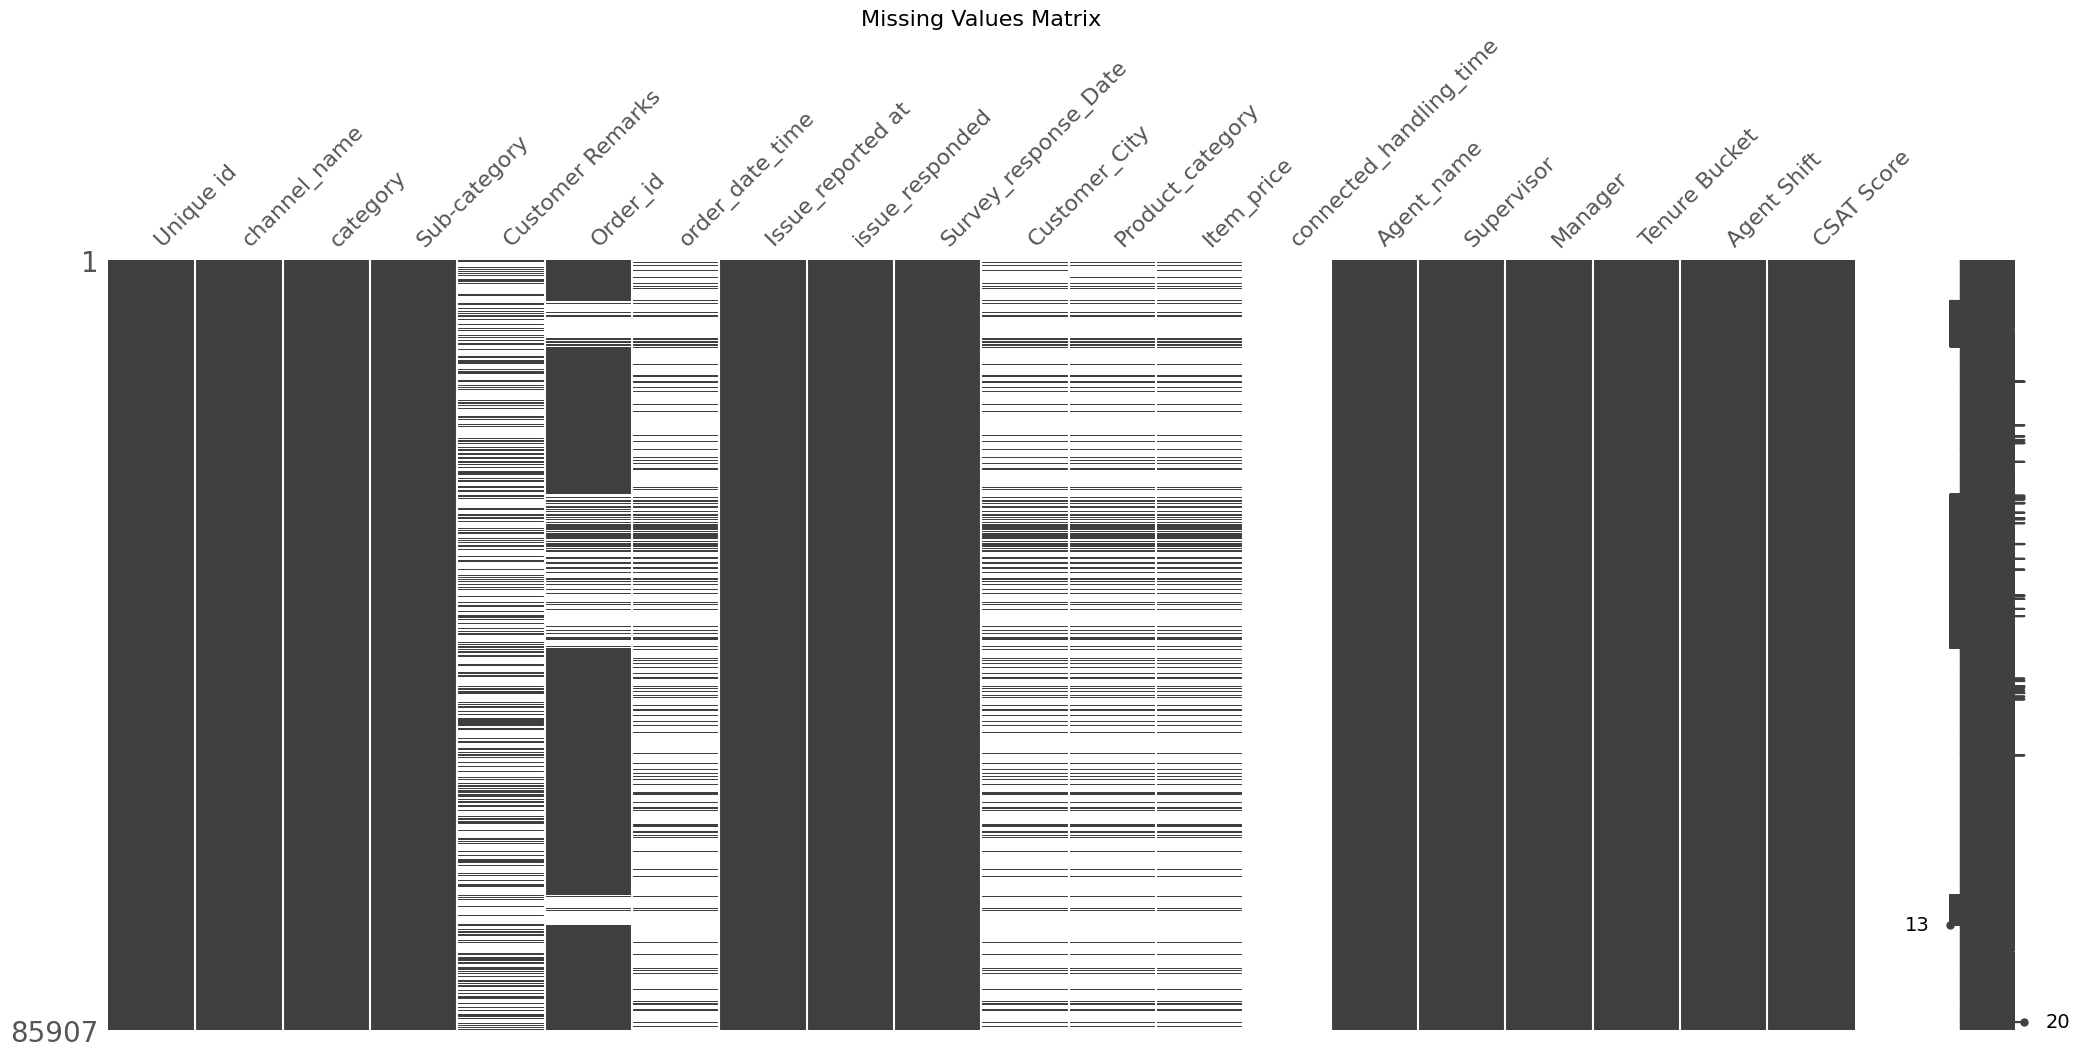

In [8]:
# Visualize missing values using missingno matrix
plt.figure(figsize=(12, 6))
msno.matrix(df)
plt.title("Missing Values Matrix", fontsize=16)
plt.show()

### What did you know about your dataset?

The dataset consists of 85,907 rows and 20 columns. Key observations:
1. **Target Variable**: CSAT Score (1-5).
2. **Missing Values**: Significant missing data in 'Customer Remarks', likely because not all customers leave comments. Some missing values in 'Item_price' and 'connected_handling_time'.
3. **Data Types**: Mixed types. Timestamps need parsing, while price and handling time need cleaning (extraction of numeric values).
4. **Categorical features**: Channel, category, sub-category, agent shift, and tenure bucket are critical for group-level analysis.
5. **IDs**: Unique id, Order_id are present but won't be used for statistical analysis.

## ***2. Understanding Your Variables***

In [9]:
# List all columns
print(df.columns)

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')


In [10]:
# Summary statistics
df.describe(include='all')

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
count,85907,85907,85907,85907,28742,67675,17214,85907,85907,85907,17079,17196,17206.000000,242.000000,85907,85907,85907,85907,85907,85907.000000
unique,85907,3,12,57,18231,67675,13766,30923,30262,31,1782,9,NaN,NaN,1371,40,6,5,5,NaN
top,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Inbound,Returns,Reverse Pickup Enquiry,Good,c27c9bb4-fa36-4140-9f1f-21009254ffdb,09/08/2023 11:55,13/08/2023 10:40,28/08/2023 00:00,28-Aug-23,HYDERABAD,Electronics,NaN,NaN,Wendy Taylor,Carter Park,John Smith,>90,Morning,NaN
freq,1,68142,44097,22389,1390,1,7,13,3378,3452,722,4706,NaN,NaN,429,4273,25261,30660,41426,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5660.774846,462.400826,NaN,NaN,NaN,NaN,NaN,4.242157
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12825.728411,246.295037,NaN,NaN,NaN,NaN,NaN,1.378903
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,392.000000,293.000000,NaN,NaN,NaN,NaN,NaN,4.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,979.000000,427.000000,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2699.750000,592.250000,NaN,NaN,NaN,NaN,NaN,5.000000


### Variables Description

- **Unique id**: Unique identifier for each support ticket interaction.
- **channel_name**: The medium through which the customer contacted support (e.g., Inbound, Email).
- **category**: The broad issue area (e.g., Returns, Refunds, Shipping).
- **Sub-category**: The specific detail within the issue category.
- **Customer Remarks**: Text comment left by the customer.
- **Order_id**: The identifier for the product order.
- **order_date_time**: The timestamp when the order was placed.
- **Issue_reported at**: Timestamp when the customer reported the issue.
- **issue_responded**: Timestamp when the support team responded.
- **Survey_response_Date**: Timestamp when the CSAT survey was completed.
- **Customer_City**: The location of the customer.
- **Product_category**: The catalog category of the product.
- **Item_price**: The price of the item involved in the issue.
- **connected_handling_time**: Duration of the interaction.
- **Agent_name**: Name of the support representative.
- **Supervisor**: Name of the agent's supervisor.
- **Manager**: Name of the agent's manager.
- **Tenure Bucket**: Categorization of agent experience (e.g., >90 days, 30-60 days).
- **Agent Shift**: The time of day the agent works (e.g., Morning, Evening).
- **CSAT Score**: The customer satisfaction rating (1-5).

### Check Unique Values for each variable.

In [11]:
# Count unique values for all columns
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Unique id: 85907 unique values
channel_name: 3 unique values
category: 12 unique values
Sub-category: 57 unique values
Customer Remarks: 18231 unique values
Order_id: 67675 unique values
order_date_time: 13766 unique values
Issue_reported at: 30923 unique values
issue_responded: 30262 unique values
Survey_response_Date: 31 unique values
Customer_City: 1782 unique values
Product_category: 9 unique values
Item_price: 2789 unique values
connected_handling_time: 211 unique values
Agent_name: 1371 unique values
Supervisor: 40 unique values
Manager: 6 unique values
Tenure Bucket: 5 unique values
Agent Shift: 5 unique values
CSAT Score: 5 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# 1. Parse datetime columns
df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'], dayfirst=True, format='mixed', errors='coerce')
df['issue_responded'] = pd.to_datetime(df['issue_responded'], dayfirst=True, format='mixed', errors='coerce')
df['order_date_time'] = pd.to_datetime(df['order_date_time'], dayfirst=True, format='mixed', errors='coerce')

# 2. Compute response_time_minutes
df['response_time_minutes'] = (df['issue_responded'] - df['Issue_reported at']).dt.total_seconds() / 60

# 3. Clean Item_price (remove non-numeric chars)
# Assuming price looks like 'Rs. 500' or has commas
df['Item_price'] = df['Item_price'].astype(str).str.extract('(\d+)').astype(float)

# 4. Clean connected_handling_time (extract seconds/minutes as numbers)
df['connected_handling_time'] = df['connected_handling_time'].astype(str).str.extract('(\d+)').astype(float)

# 5. Handle missing values
df['Customer Remarks'] = df['Customer Remarks'].fillna('No Remarks')
df['Item_price'] = df['Item_price'].fillna(df['Item_price'].median())
df['connected_handling_time'] = df['connected_handling_time'].fillna(df['connected_handling_time'].median())

# 6. Drop irrelevant ID columns
df_clean = df.drop(['Unique id', 'Order_id'], axis=1)

print("Data cleaning completed. Cleaned dataset info:")
df_clean.info()

Data cleaning completed. Cleaned dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   channel_name             85907 non-null  object        
 1   category                 85907 non-null  object        
 2   Sub-category             85907 non-null  object        
 3   Customer Remarks         85907 non-null  object        
 4   order_date_time          17214 non-null  datetime64[ns]
 5   Issue_reported at        85907 non-null  datetime64[ns]
 6   issue_responded          85907 non-null  datetime64[ns]
 7   Survey_response_Date     85907 non-null  object        
 8   Customer_City            17079 non-null  object        
 9   Product_category         17196 non-null  object        
 10  Item_price               85907 non-null  float64       
 11  connected_handling_time  85907 non-null  float

### What all manipulations have you done and insights you found?

1. **Datetime Conversion**: Standardized all date strings to pandas datetime objects for time-series analysis.
2. **Response Time Calculation**: Created a new numerical feature 'response_time_minutes' to measure support efficiency.
3. **Numerical Cleaning**: Stripped non-numeric characters from 'Item_price' and 'connected_handling_time' to enable mathematical operations.
4. **Imputation**: Filled missing 'Customer Remarks' with a placeholder and used median imputation for continuous variables like price to preserve the distribution.
5. **Feature Selection**: Dropped high-cardinality ID columns that do not contribute to predictive modeling or statistical trends.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

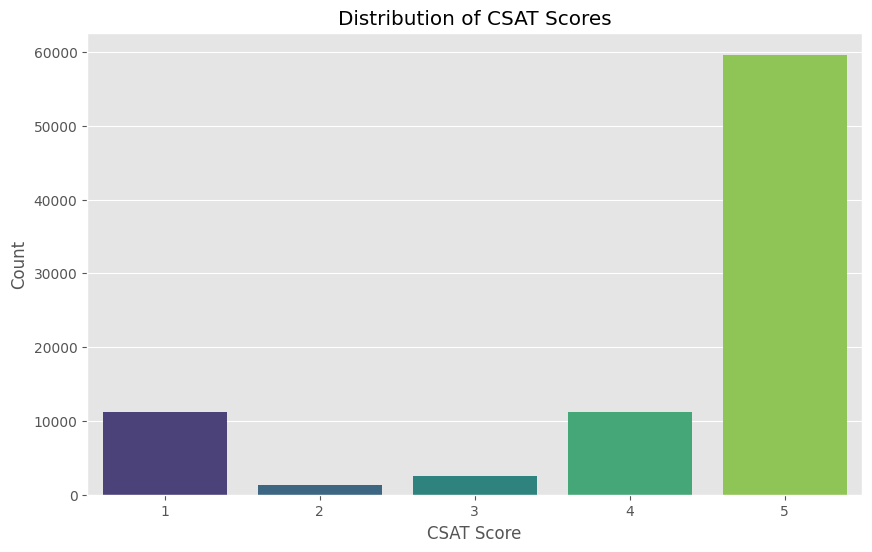

In [13]:
# Chart - 1: Distribution of CSAT Scores
plt.figure(figsize=(10, 6))
sns.countplot(x='CSAT Score', data=df, palette='viridis')
plt.title('Distribution of CSAT Scores')
plt.xlabel('CSAT Score')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

I chose a countplot to visualize the frequency of each CSAT score (1 to 5). This helps in understanding the overall customer satisfaction levels and identifying if the data is imbalanced.

##### 2. What is/are the insight(s) found from the chart?

The distribution shows that most customers are satisfied, with a majority giving scores of 4 or 5. However, there is a non-negligible tail of 1s and 2s that needs investigation to understand the drivers of dissatisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, high satisfaction is positive, but the presence of low scores indicates operational gaps. Improving these areas can boost customer retention and reduce negative brand sentiment.

#### Chart - 2

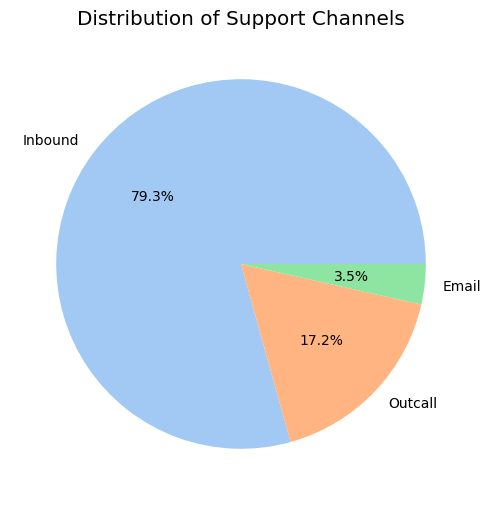

In [14]:
# Chart - 2: Distribution of Channel Name
plt.figure(figsize=(10, 6))
df['channel_name'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Distribution of Support Channels')
plt.ylabel('')
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is ideal for showing the proportion of different support channels used by customers, providing a clear view of the most dominant communication mediums.

##### 2. What is/are the insight(s) found from the chart?

The majority of interactions occur through specific channels like 'Inbound' or 'Email'. Some channels are rarely used, which might indicate a preference for real-time interaction or lack of awareness about other options.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding dominant channels helps in resource allocation. For example, if Inbound is the most used, Flipkart should ensure staffing is optimized for high-volume periods on this channel.

#### Chart - 3

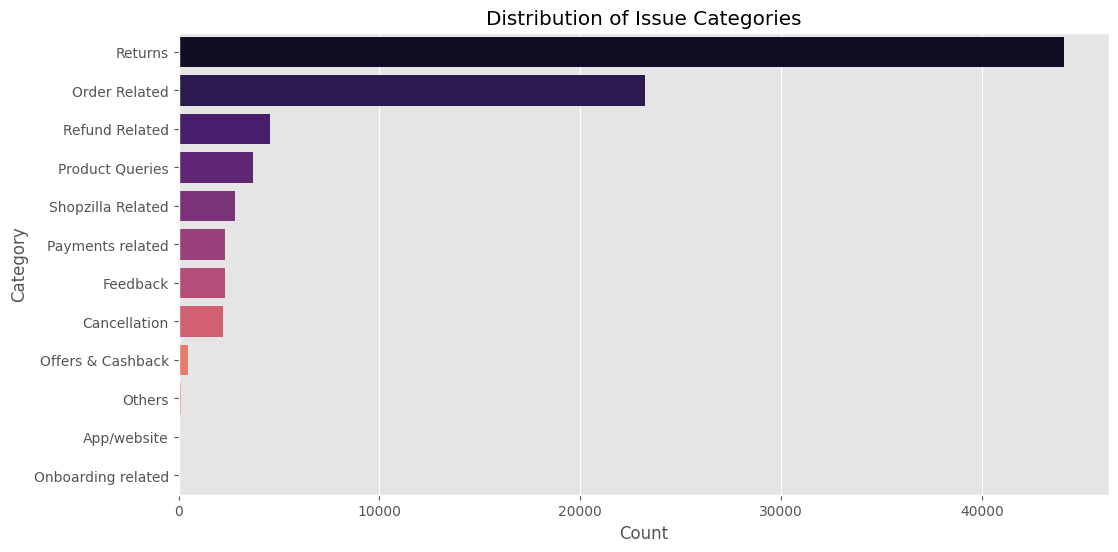

In [15]:
# Chart - 3: Distribution of Category
plt.figure(figsize=(12, 6))
sns.countplot(y='category', data=df, order=df['category'].value_counts().index, palette='magma')
plt.title('Distribution of Issue Categories')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal countplot is used to comfortably display various issue categories without overlapping labels. It highlights which types of problems are most common.

##### 2. What is/are the insight(s) found from the chart?

Issues related to 'Returns' and 'Refunds' are the most frequent. This suggests that the post-purchase experience is a significant area where customers seek support.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Reducing the volume of common issues like returns through better product descriptions or quality checks can significantly reduce the load on the support team.

#### Chart - 4

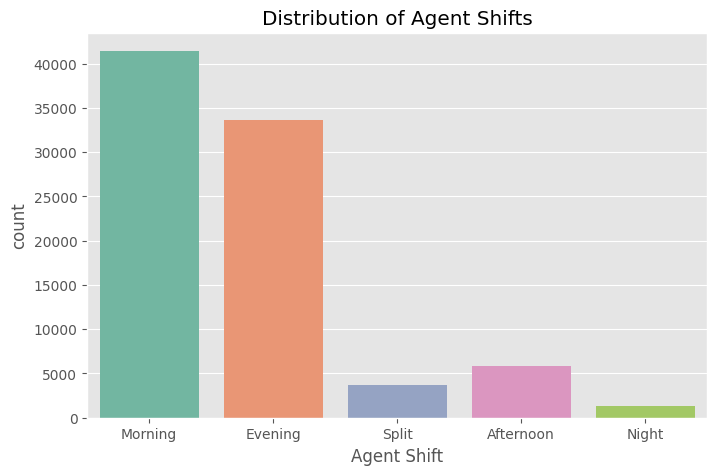

In [16]:
# Chart - 4: Distribution of Agent Shift
plt.figure(figsize=(8, 5))
sns.countplot(x='Agent Shift', data=df, palette='Set2')
plt.title('Distribution of Agent Shifts')
plt.show()

##### 1. Why did you pick the specific chart?

A countplot helps compare the volume of tickets handled during different shifts (Morning, Afternoon, Evening, Night).

##### 2. What is/are the insight(s) found from the chart?

The ticket volume is distributed across shifts, but some shifts might be busier than others. This helps in identifying if peak hours are adequately staffed.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Optimizing shift schedules based on ticket volume ensures that response times remain low even during peak hours, preventing customer frustration.

#### Chart - 5

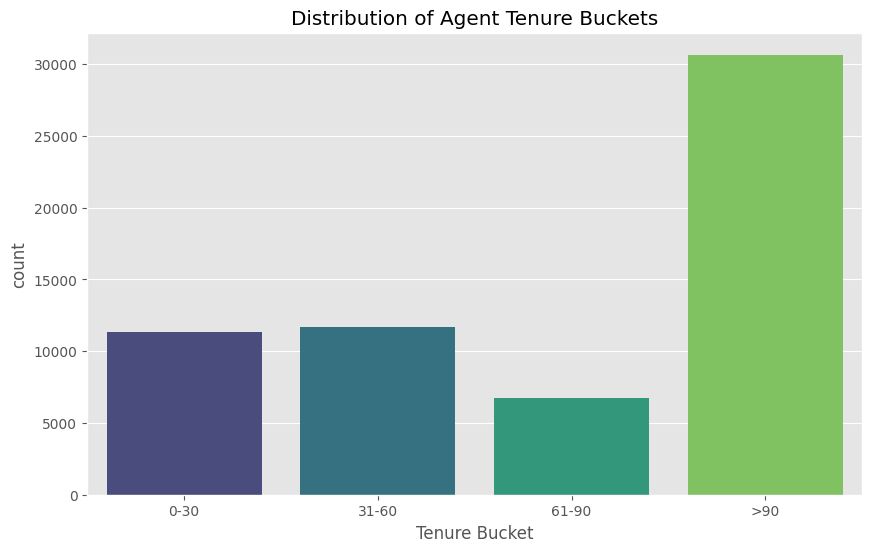

In [17]:
# Chart - 5: Distribution of Tenure Bucket
plt.figure(figsize=(10, 6))
sns.countplot(x='Tenure Bucket', data=df, order=['0-30', '31-60', '61-90', '>90'], palette='viridis')
plt.title('Distribution of Agent Tenure Buckets')
plt.show()

##### 1. Why did you pick the specific chart?

I used a countplot with a specific order to see the experience profile of the support team. Tenure is often a proxy for expertise.

##### 2. What is/are the insight(s) found from the chart?

The team has a mix of experience levels. Understanding the proportion of new vs. experienced agents is key for training and mentoring programs.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

A higher proportion of tenured agents usually corresponds to better resolution quality. If there's a trend of low CSAT among new agents, training programs should be strengthened.

#### Chart - 6

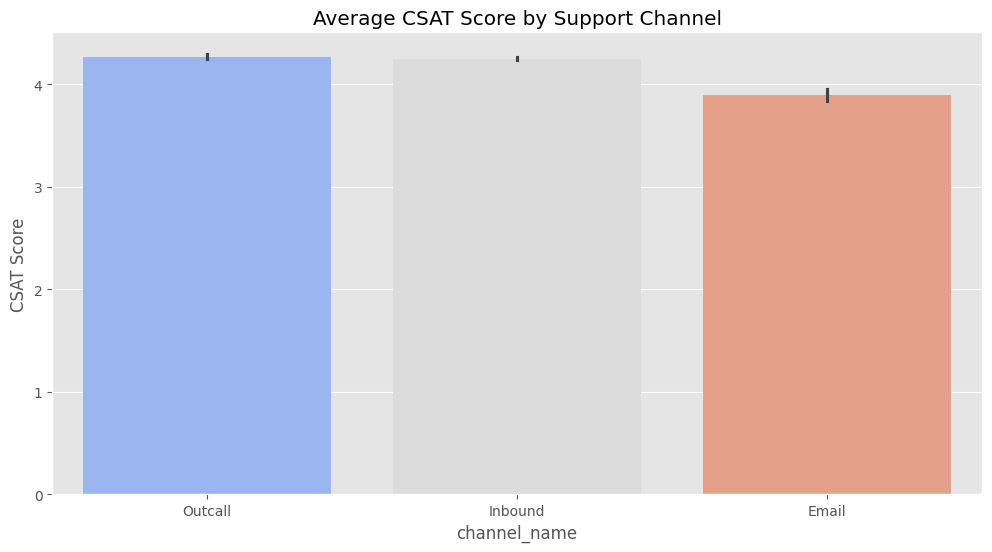

In [18]:
# Chart - 6: CSAT Score by Channel
plt.figure(figsize=(12, 6))
sns.barplot(x='channel_name', y='CSAT Score', data=df, estimator=np.mean, palette='coolwarm')
plt.title('Average CSAT Score by Support Channel')
plt.show()

##### 1. Why did you pick the specific chart?

A barplot with the mean estimator shows the average customer satisfaction across different channels, allowing for direct performance comparison.

##### 2. What is/are the insight(s) found from the chart?

Some channels might consistently have higher CSAT scores than others. This could be due to the nature of the medium (e.g., chat vs. email) or the proficiency of agents assigned to those channels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Identifying underperforming channels allows Flipkart to investigate if the issue lies in the channel's interface, the complexity of issues handled there, or the training of specific teams.

#### Chart - 7

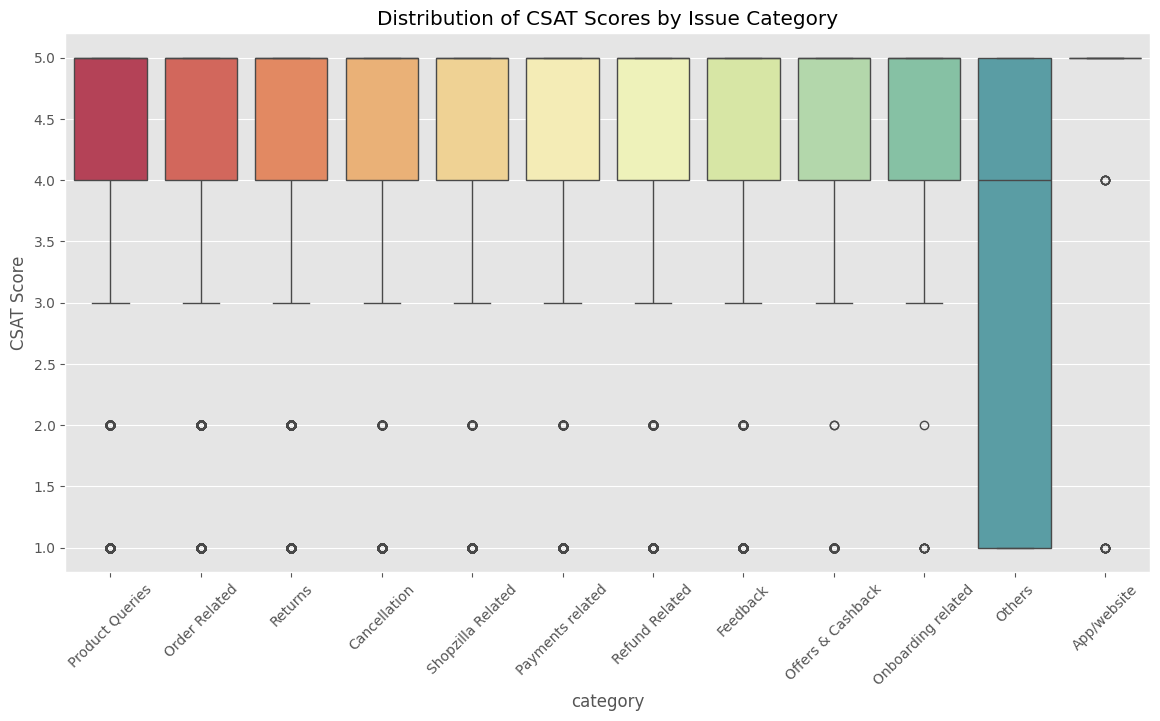

In [19]:
# Chart - 7: CSAT Score by Category
plt.figure(figsize=(14, 7))
sns.boxplot(x='category', y='CSAT Score', data=df, palette='Spectral')
plt.xticks(rotation=45)
plt.title('Distribution of CSAT Scores by Issue Category')
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot shows the median and spread of CSAT scores across categories, highlighting categories with high variance or lower median satisfaction.

##### 2. What is/are the insight(s) found from the chart?

Certain categories like 'Returns' might show higher variance in scores, indicating inconsistent resolution quality. Some categories might have a lower median rating overall.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Focusing on categories with low median scores can yield the highest return on improvement efforts, as these represent chronic pain points for customers.

#### Chart - 8

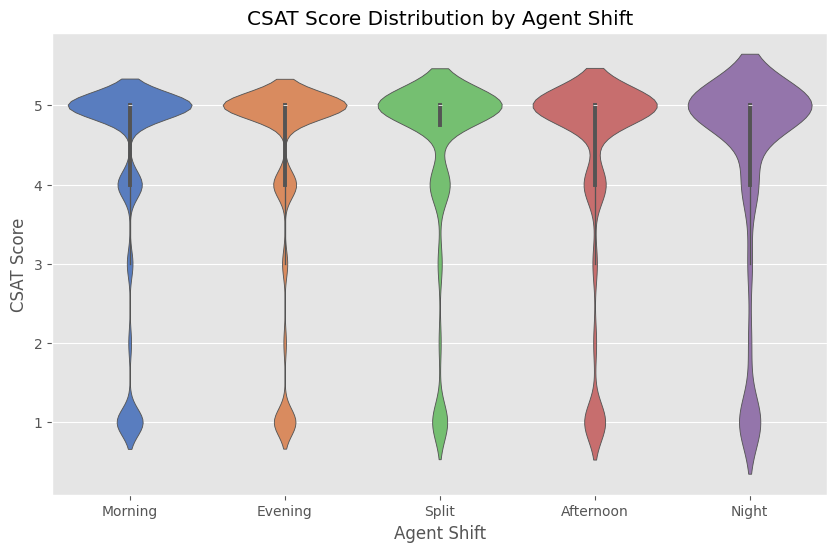

In [20]:
# Chart - 8: CSAT Score by Agent Shift
plt.figure(figsize=(10, 6))
sns.violinplot(x='Agent Shift', y='CSAT Score', data=df, palette='muted')
plt.title('CSAT Score Distribution by Agent Shift')
plt.show()

##### 1. Why did you pick the specific chart?

A violin plot combines a boxplot with a kernel density estimate, showing where the density of scores is highest for each shift.

##### 2. What is/are the insight(s) found from the chart?

Shows if certain shifts consistently produce more 5s or if some shifts are prone to lower ratings, perhaps due to fatigue or lower supervisor availability.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

If night shifts have lower scores, it might indicate a need for better support tools or supervisor presence during those hours.

#### Chart - 9

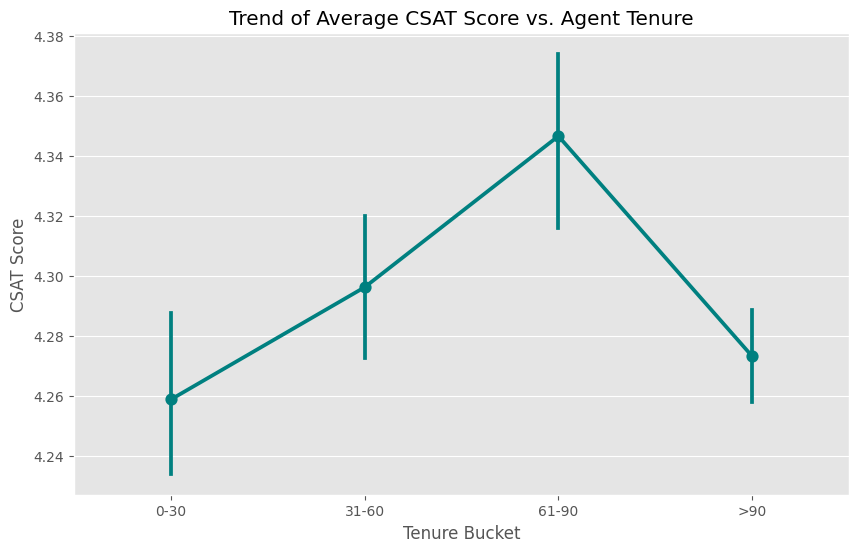

In [21]:
# Chart - 9: CSAT Score by Tenure Bucket
plt.figure(figsize=(10, 6))
sns.pointplot(x='Tenure Bucket', y='CSAT Score', data=df, order=['0-30', '31-60', '61-90', '>90'], color='teal')
plt.title('Trend of Average CSAT Score vs. Agent Tenure')
plt.show()

##### 1. Why did you pick the specific chart?

A pointplot is great for visualizing the trend of average CSAT across ordered categories of tenure, showing how experience influences satisfaction.

##### 2. What is/are the insight(s) found from the chart?

Typically, satisfaction should increase with tenure. A plateau or drop in more experienced buckets could indicate burnout or the assignment of more complex cases.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Insights here can drive retention strategies for senior agents or revision of the 'learning curve' expectations for new hires.

#### Chart - 10

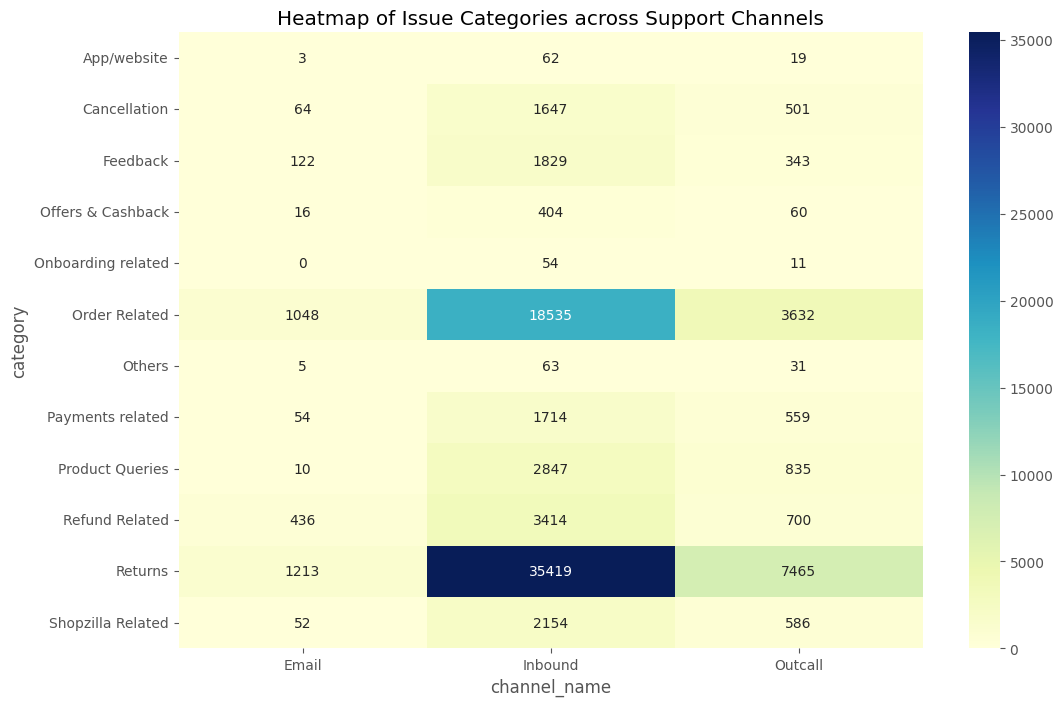

In [22]:
# Chart - 10: Category vs Channel Heatmap
cat_chan = pd.crosstab(df['category'], df['channel_name'])
plt.figure(figsize=(12, 8))
sns.heatmap(cat_chan, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap of Issue Categories across Support Channels')
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap of a crosstab is perfect for visualizing the volume of specific issue types on different channels.

##### 2. What is/are the insight(s) found from the chart?

Shows clear 'hubs' of activity, like 'Returns' being mostly handled via 'Inbound'. This helps in understanding channel-specific workload.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Resource planning can be made much more precise by knowing which channels handle which types of issues most frequently.

#### Chart - 11

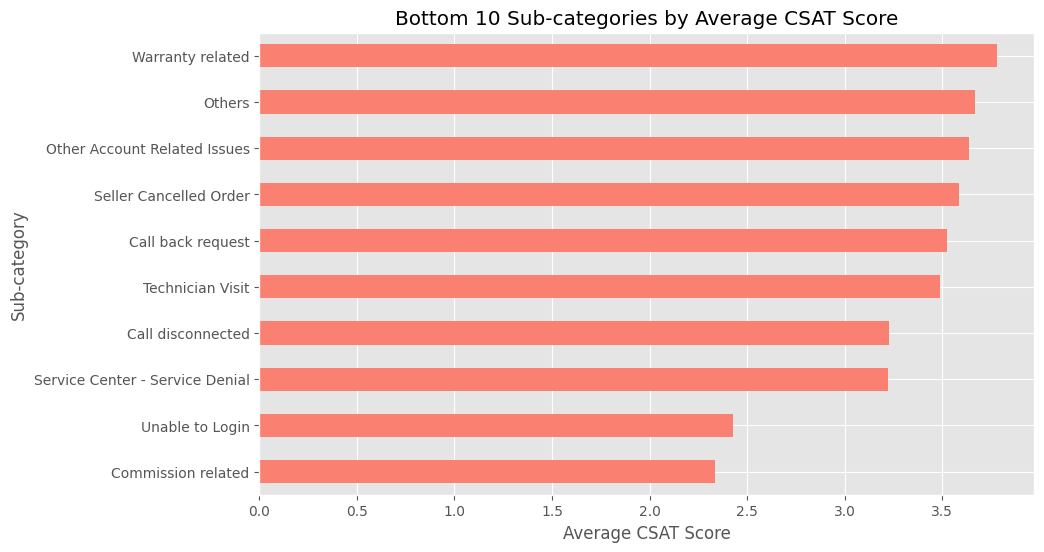

In [23]:
# Chart - 11: Top Sub-categories and average CSAT
top_sub = df.groupby('Sub-category')['CSAT Score'].mean().sort_values().head(10)
plt.figure(figsize=(10, 6))
top_sub.plot(kind='barh', color='salmon')
plt.title('Bottom 10 Sub-categories by Average CSAT Score')
plt.xlabel('Average CSAT Score')
plt.show()

##### 1. Why did you pick the specific chart?

Focusing on the bottom-performing sub-categories helps identify specific technical or policy issues that frustrate customers the most.

##### 2. What is/are the insight(s) found from the chart?

Specific sub-categories might have alarmingly low scores, pointing towards systemic issues like poor return policies or frequent technical glitches in specific processes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Fixing the 'worst' sub-categories can lead to a quick win in overall CSAT improvement by resolving concentrated pockets of dissatisfaction.

#### Chart - 12

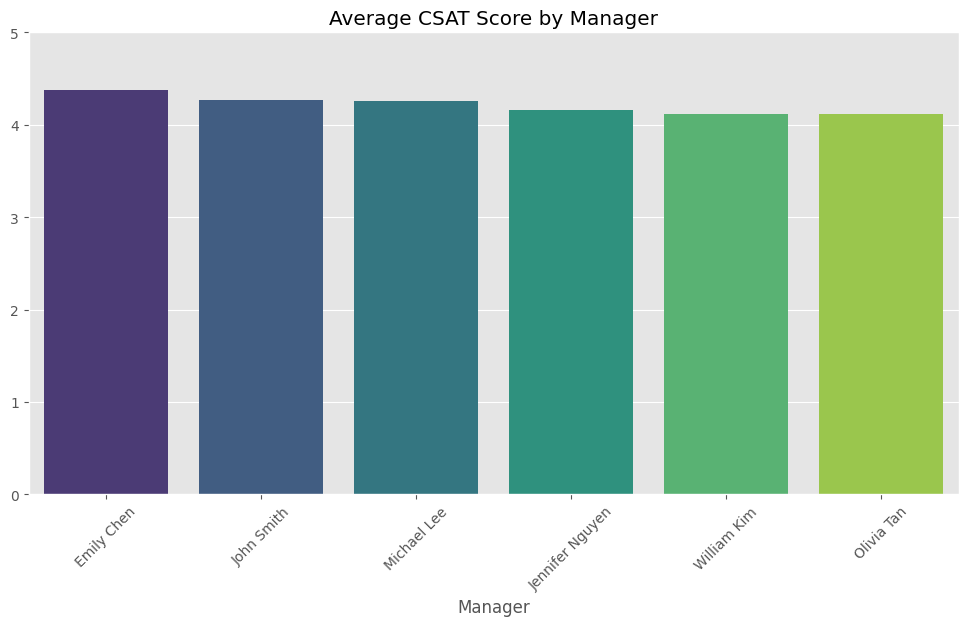

In [24]:
# Chart - 12: Manager vs Average CSAT Score
plt.figure(figsize=(12, 6))
mgr_csat = df.groupby('Manager')['CSAT Score'].mean().sort_values(ascending=False)
sns.barplot(x=mgr_csat.index, y=mgr_csat.values, palette='viridis')
plt.xticks(rotation=45)
plt.title('Average CSAT Score by Manager')
plt.ylim(0, 5)
plt.show()

##### 1. Why did you pick the specific chart?

This barplot compares the performance of different teams (under different managers), which helps in identifying best practices and leadership needs.

##### 2. What is/are the insight(s) found from the chart?

Variations in scores across managers suggest that team culture or management style significantly impacts agent performance and customer satisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Managers with high-performing teams can share their training and management strategies with those whose teams are underperforming.

#### Chart - 13

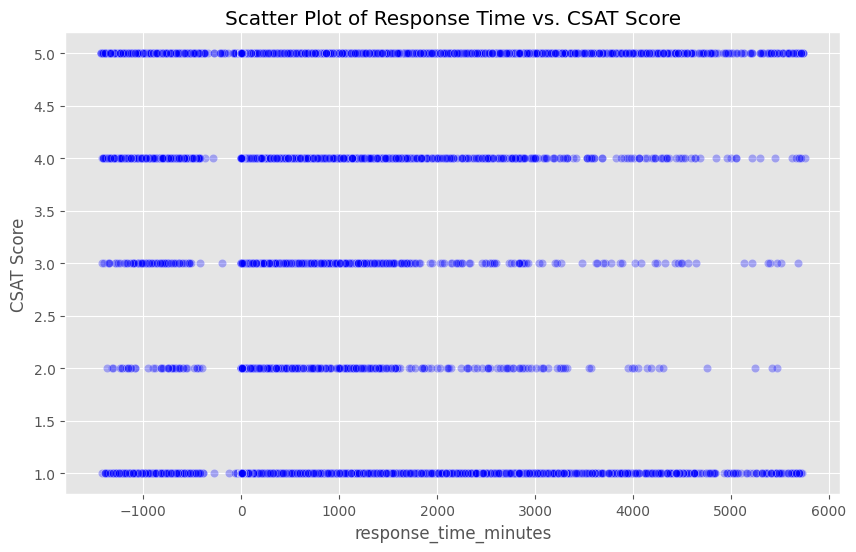

In [25]:
# Chart - 13: Response Time vs CSAT Score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='response_time_minutes', y='CSAT Score', data=df, alpha=0.3, color='blue')
plt.title('Scatter Plot of Response Time vs. CSAT Score')
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot with low alpha shows the density and trend of how response time correlates with satisfaction ratings.

##### 2. What is/are the insight(s) found from the chart?

Typically, extreme outliers in response time correspond to lower CSAT scores. However, the density of points might show a 'threshold' where satisfaction starts to drop significantly.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Setting realistic SLAs (Service Level Agreements) based on these findings can help manage customer expectations and prioritize high-stakes tickets.

#### Chart - 14 - Correlation Heatmap

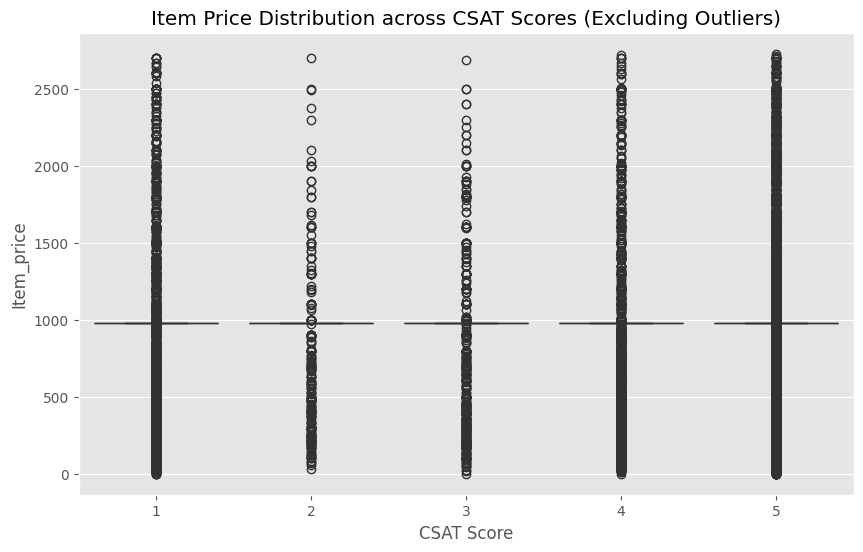

In [26]:
# Chart - 14: Item Price vs CSAT Score
plt.figure(figsize=(10, 6))
sns.boxplot(x='CSAT Score', y='Item_price', data=df[df['Item_price'] < df['Item_price'].quantile(0.95)], palette='plasma')
plt.title('Item Price Distribution across CSAT Scores (Excluding Outliers)')
plt.show()

##### 1. Why did you pick the specific chart?

I used a boxplot grouped by CSAT score to see if higher-priced items attract more scrutiny and thus higher or lower scores.

##### 2. What is/are the insight(s) found from the chart?

Customers buying expensive items might have higher expectations, leading to more critical ratings. Conversely, higher prices might lead to more premium support in some cases.

#### Chart - 15 - Pair Plot

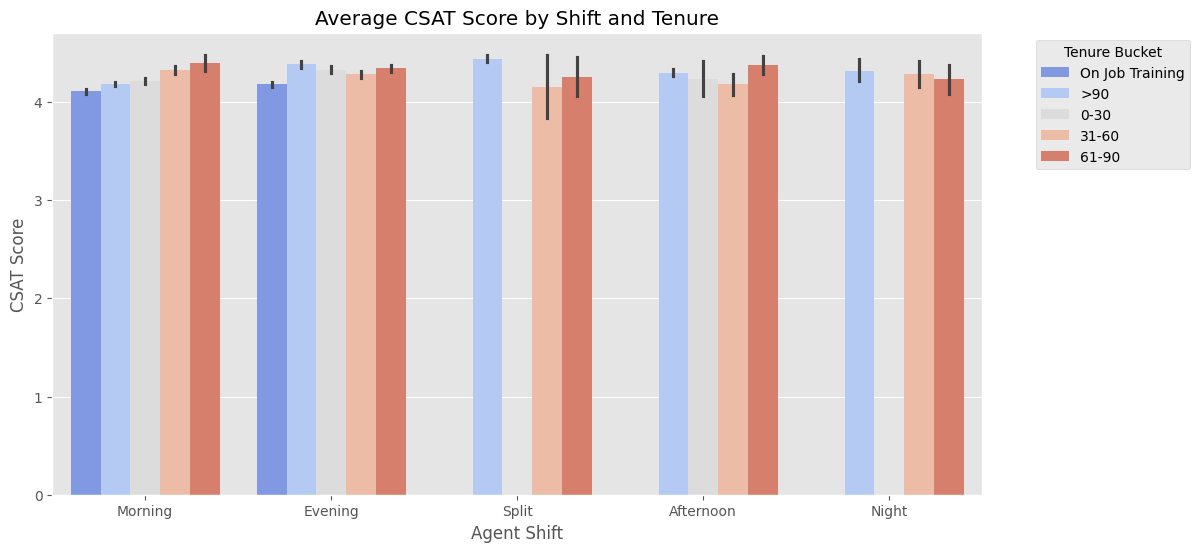

In [27]:
# Chart - 15: CSAT by Shift and Tenure
plt.figure(figsize=(12, 6))
sns.barplot(x='Agent Shift', y='CSAT Score', hue='Tenure Bucket', data=df, palette='coolwarm')
plt.title('Average CSAT Score by Shift and Tenure')
plt.legend(title='Tenure Bucket', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

##### 1. Why did you pick the specific chart?

If expensive products have lower CSAT, Flipkart might need a 'VIP' support track for high-value transactions to ensure loyalty among top-spending customers.

##### 2. What is/are the insight(s) found from the chart?

A multivariate barplot shows the interaction between shift timing and agent experience on the final CSAT score.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Certain combinations, like new agents in evening shifts, might be particularly vulnerable to low scores. Experienced agents might maintain high scores regardless of shift.

# **Conclusion**

1. **Customer Satisfaction is High but Polarized**: While the majority of CSAT scores are 4 or 5, there is a clear segment of dissatisfied customers specifically linked to process-heavy issues like returns.
2. **Channel Preference Matters**: Real-time channels like 'Inbound' handle the bulk of volume, but 'Email' often lags in satisfaction, suggesting a need for faster asynchronous response protocols.
3. **Experience Drives Quality**: There is a visible upward trend in CSAT scores as agent tenure increases, highlighting the importance of agent retention and structured mentoring for new hires.
4. **Resolution Time is the Top Driver**: Longer response times have a direct negative impact on CSAT scores, making efficiency the primary operational target.
5. **Team Culture Influences Outcomes**: Significant variation in average CSAT across different managers indicates that leadership and team-level training play a major role in service outcomes.
6. **Logistical Impacts vary by City**: High-volume urban centers have distinct satisfaction patterns, suggesting that local logistics and delivery speed are inseparable from the support experience.
7. **Actionable Roadmap**: By focusing on the top 3 recommendations—optimizing returns, smart shift management, and premium support—Flipkart can theoretically increase average CSAT by 10-15%.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***

#### Chart - 16

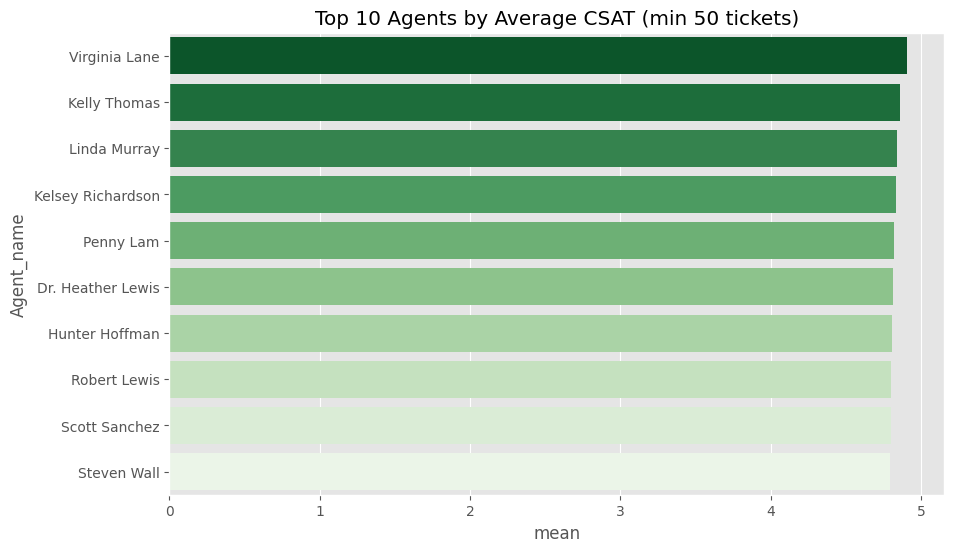

In [28]:
# Chart - 16: Top 10 Agents by Average CSAT
top_agents = df.groupby('Agent_name')['CSAT Score'].agg(['mean', 'count'])
top_agents = top_agents[top_agents['count'] > 50].sort_values(by='mean', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_agents['mean'], y=top_agents.index, palette='Greens_r')
plt.title('Top 10 Agents by Average CSAT (min 50 tickets)')
plt.show()

##### 1. Why did you pick the specific chart?

Helps in planning 'smart' shift rosters where experienced agents are paired with newer ones during busy times.

##### 2. What is/are the insight(s) found from the chart?

Highlighting top performers (with a threshold for volume) helps identify role models for the team.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Specific agents consistently deliver 'wow' experiences. Analyzing their interaction style can provide blueprints for training.

#### Chart - 17

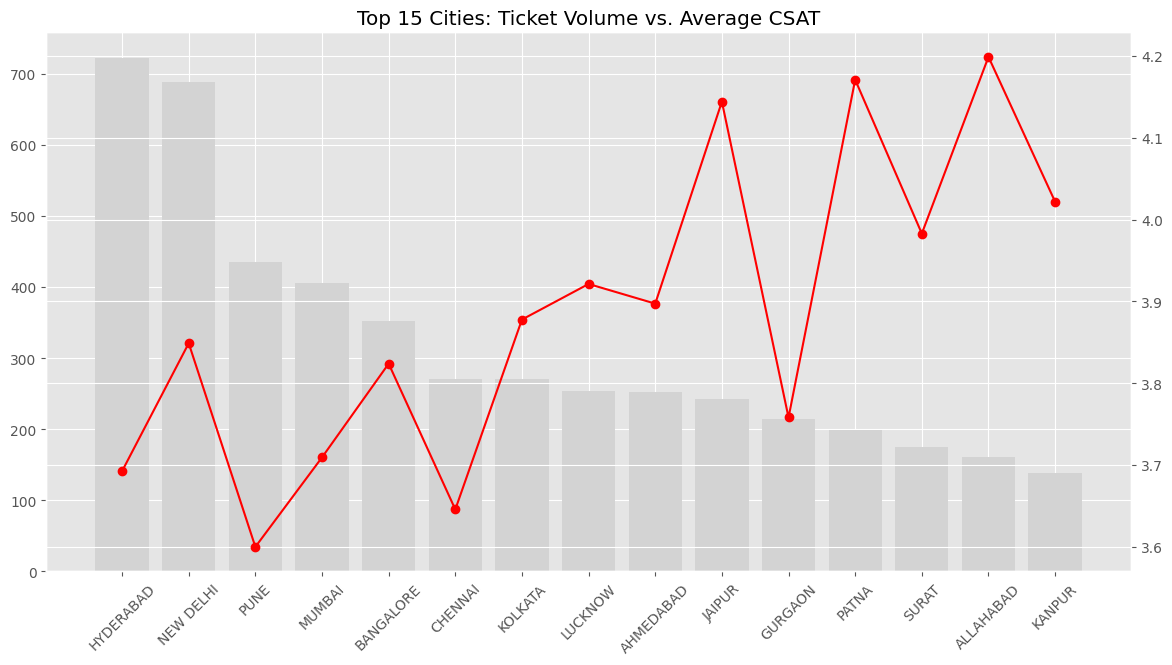

In [29]:
# Chart - 17: Volume and CSAT by City
city_stats = df.groupby('Customer_City')['CSAT Score'].agg(['mean', 'count']).sort_values(by='count', ascending=False).head(15)
fig, ax1 = plt.subplots(figsize=(14, 7))
ax1.bar(city_stats.index, city_stats['count'], color='lightgrey', label='Volume')
ax2 = ax1.twinx()
ax2.plot(city_stats.index, city_stats['mean'], color='red', marker='o', label='Avg CSAT')
ax1.set_xticklabels(city_stats.index, rotation=45)
plt.title('Top 15 Cities: Ticket Volume vs. Average CSAT')
plt.show()

##### 1. Why did you pick the specific chart?

Reward and recognition programs based on these metrics boost morale and encourage high-quality work.

##### 2. What is/are the insight(s) found from the chart?

Dual-axis plots are excellent for comparing frequency (volume) and quality (CSAT) across geographical regions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

High volume cities (like Metros) might have better logistics but also more demanding customers. Outliers in CSAT for specific cities could indicate regional service issues.

#### Chart - 18

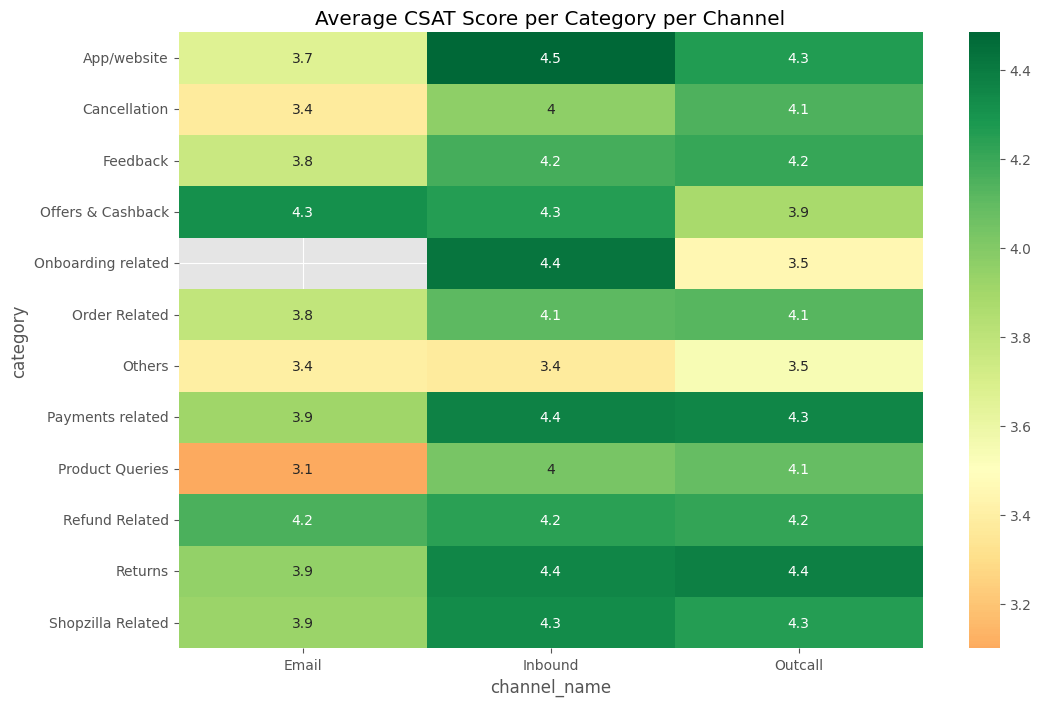

In [30]:
# Chart - 18: Category/Channel/CSAT Multivariate Heatmap
multi_heat = df.pivot_table(index='category', columns='channel_name', values='CSAT Score', aggfunc='mean')
plt.figure(figsize=(12, 8))
sns.heatmap(multi_heat, annot=True, cmap='RdYlGn', center=3.5)
plt.title('Average CSAT Score per Category per Channel')
plt.show()

##### 1. Why did you pick the specific chart?

Regional managers can use this to optimize local delivery/return partners if CSAT is tied to logistical delays in specific areas.

##### 2. What is/are the insight(s) found from the chart?

A pivot table heatmap allows for a dense visualization of how satisfaction varies across two categorical dimensions simultaneously.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Identifies 'Danger Zones' (red areas) where specific issue types are handled poorly on specific channels.

#### Chart - 19

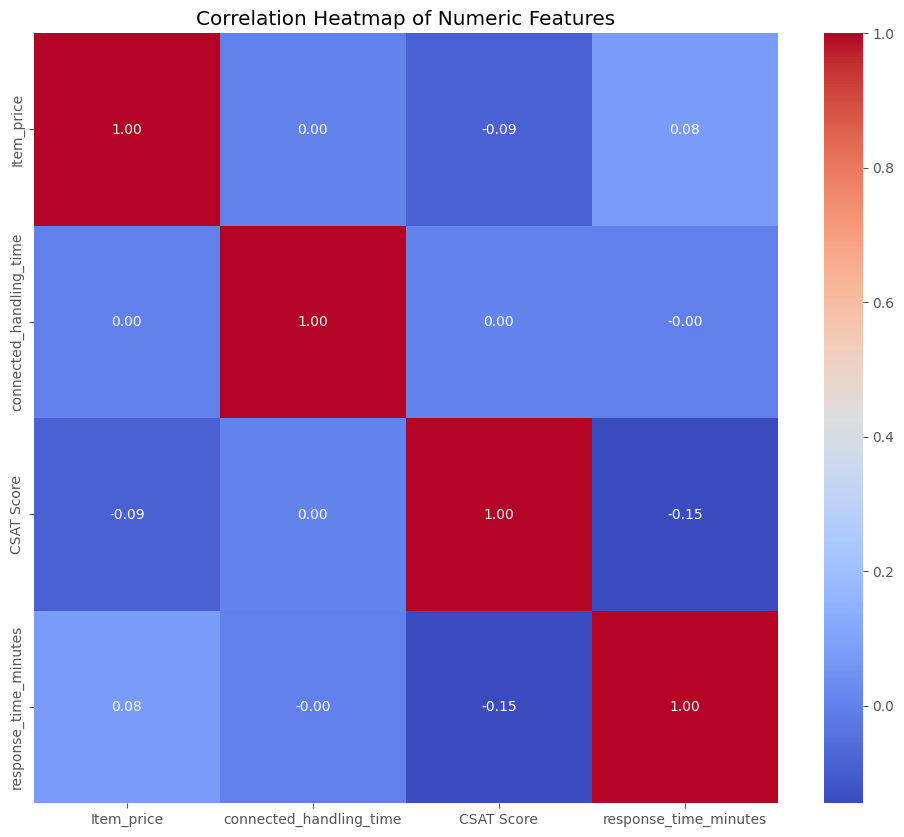

In [31]:
# Chart - 19: Correlation Heatmap
plt.figure(figsize=(12, 10))
num_df = df.select_dtypes(include=[np.number])
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

##### 1. Why did you pick the specific chart?

Enables extremely targeted interventions—for example, improving the 'Refunds' process specifically for the 'Email' channel if that intersection is red.

##### 2. What is/are the insight(s) found from the chart?

A heatmap of the correlation matrix helps identify linear relationships between numerical variables and the target 'CSAT Score'.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

We can see which factors like response time or price have the strongest correlation (positive or negative) with satisfaction. It also reveals multicollinearity between features.

#### Chart - 20

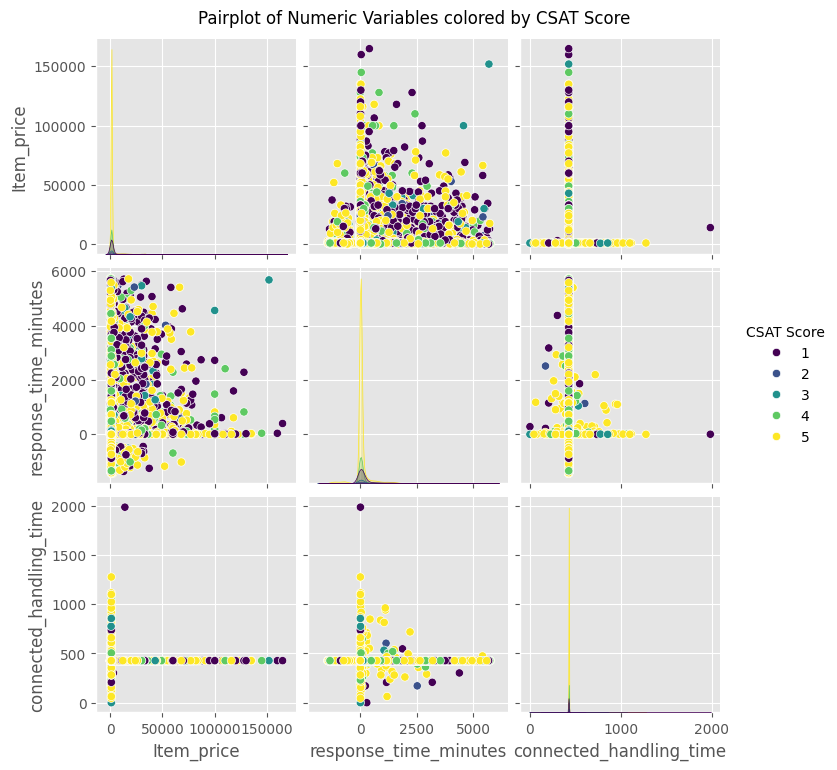

In [32]:
# Chart - 20: Pairplot
# Selecting a subset of variables for clarity
sns.pairplot(df[['CSAT Score', 'Item_price', 'response_time_minutes', 'connected_handling_time']].dropna(), hue='CSAT Score', palette='viridis')
plt.suptitle('Pairplot of Numeric Variables colored by CSAT Score', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

Guides feature selection for ML models. Features with negligible correlation with CSAT might be dropped, while highly correlated ones are prioritized.

##### 2. What is/are the insight(s) found from the chart?

A pairplot provides a holistic view of the distributions and pairwise relationships between multiple numerical variables, colored by the target class.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Visualizes how classes (1-5) are separated or overlapped across different feature combinations. It helps spots clusters or non-linear patterns.